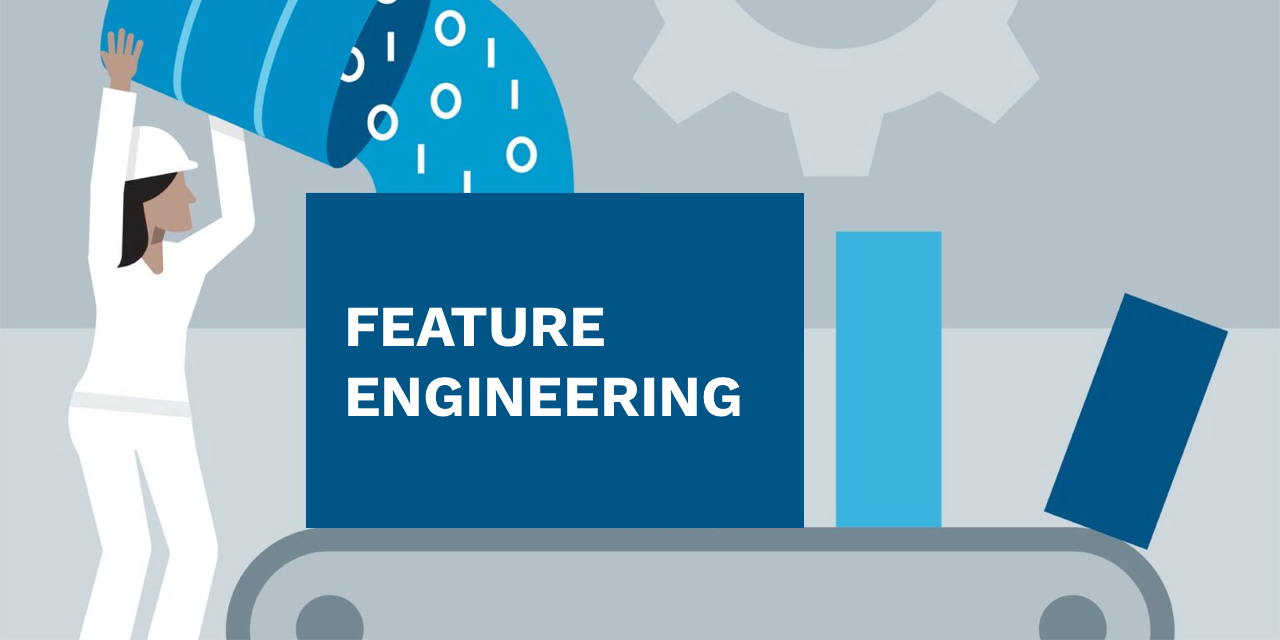

# 04. Feature Engineering Report

## Problem Statement

The cleaned branch performance dataset contains useful raw business metrics such as orders, revenue, ratings, customers, complaints, and delivery time.

However, raw columns alone may not fully capture business behavior. For example, total complaints alone does not explain whether a branch is truly problematic unless we compare complaints with total orders. Similarly, repeat customers become more meaningful when converted into repeat customer rate.

Therefore, feature engineering is required to create meaningful business metrics that can help machine learning models and business owners understand branch performance more clearly.

---

## Business Objective

The objective of this notebook is to transform cleaned branch-level data into stronger business features.

These engineered features will help:

- Measure revenue efficiency
- Understand customer loyalty
- Measure complaint intensity
- Track customer acquisition
- Understand service quality
- Identify operational risk
- Prepare the dataset for machine learning models

---

## Project Lifecycle Position

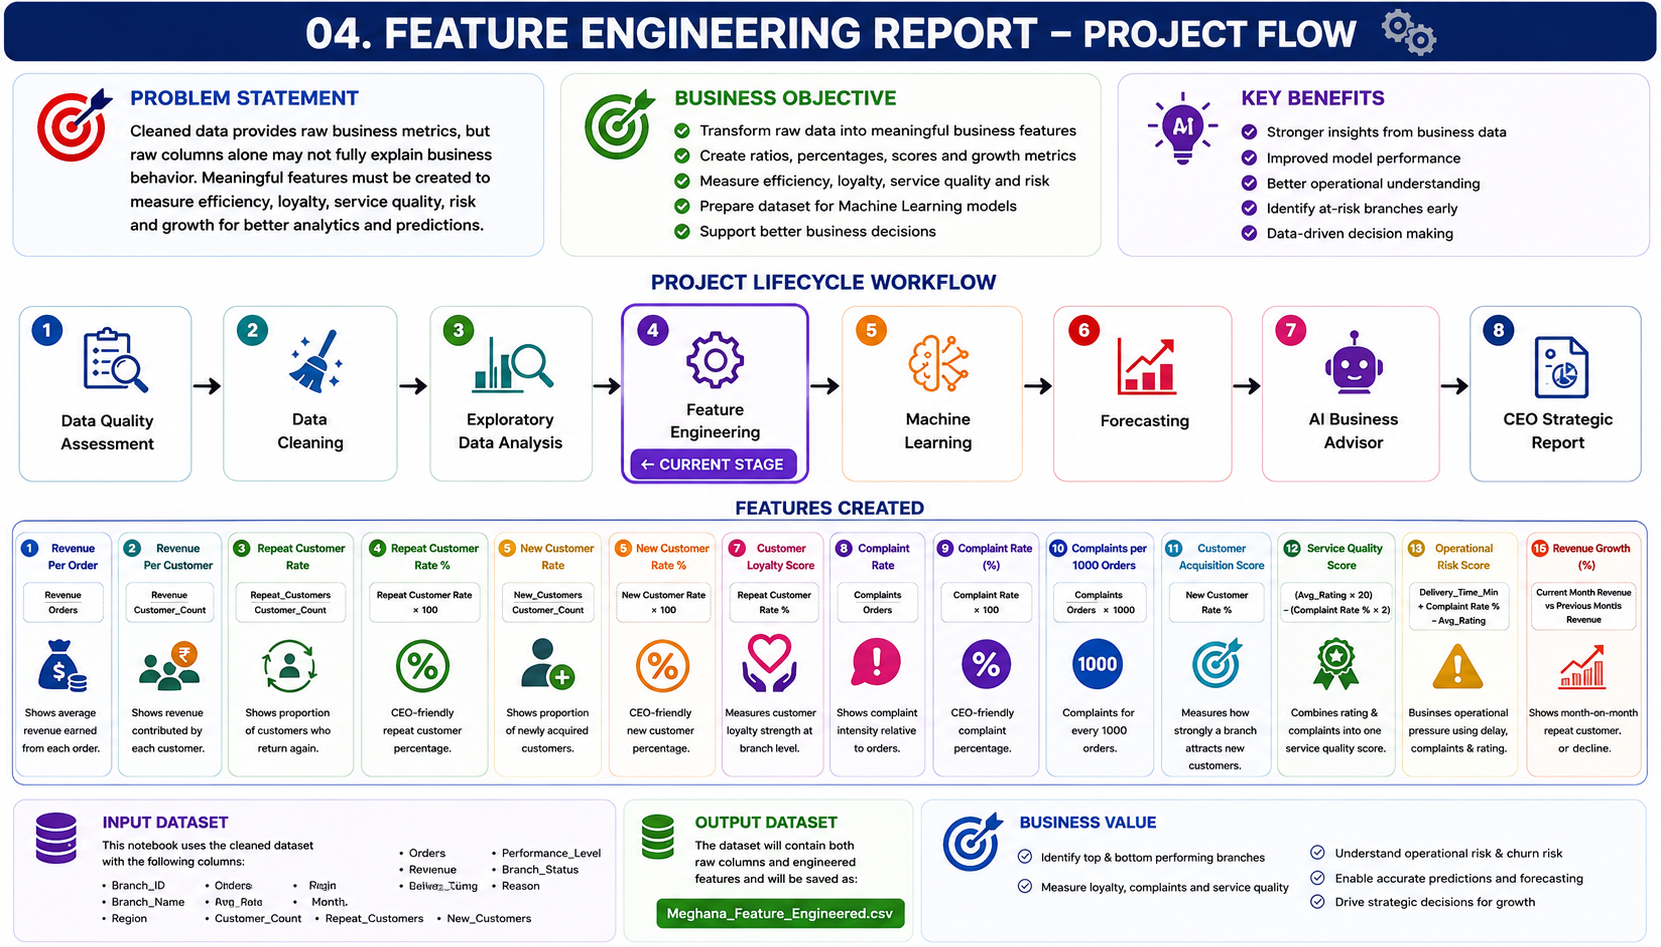

Current Stage:

Feature Engineering

Workflow:

1. Data Quality Assessment
2. Data Cleaning
3. Exploratory Data Analysis
4. Feature Engineering ← Current Stage
5. Machine Learning
6. Forecasting
7. AI Business Advisor
8. CEO Strategic Report

---

## Input Dataset Columns

The feature engineering process starts with the following cleaned columns:

- Branch_ID
- Branch_Name
- Region
- Month
- Orders
- Revenue
- Avg_Rating
- Customer_Count
- Repeat_Customers
- New_Customers
- Complaints
- Delivery_Time_Min
- Performance_Level
- Branch_Status
- Reason

---

## Feature Engineering Strategy

The new features are created from existing business metrics.

Instead of only looking at raw numbers, we create ratios, percentages, scores, and growth indicators.

This helps both:

- Machine Learning Models
- Business Decision Makers

---

## Features Created

### 1. Revenue Per Order

Formula:

Revenue / Orders

Purpose:

Shows how much money is earned from each order on average.

---

### 2. Revenue Per Customer

Formula:

Revenue / Customer_Count

Purpose:

Shows how much revenue each customer contributes.

---

### 3. Repeat Customer Rate

Formula:

Repeat_Customers / Customer_Count

Purpose:

Shows the proportion of customers who return again.

---

### 4. Repeat Customer Rate Percentage

Formula:

Repeat_Customer_Rate × 100

Purpose:

CEO-friendly version of repeat customer rate.

---

### 5. New Customer Rate

Formula:

New_Customers / Customer_Count

Purpose:

Shows how many customers are newly acquired.

---

### 6. New Customer Rate Percentage

Formula:

New_Customer_Rate × 100

Purpose:

CEO-friendly version of new customer rate.

---

### 7. Customer Loyalty Score

Formula:

Repeat_Customer_Rate_Pct

Purpose:

Measures customer loyalty strength at branch level.

---

### 8. Complaint Rate

Formula:

Complaints / Orders

Purpose:

Shows complaint intensity relative to order volume.

---

### 9. Complaint Rate Percentage

Formula:

Complaint_Rate × 100

Purpose:

CEO-friendly complaint percentage.

---

### 10. Complaints Per 1000 Orders

Formula:

(Complaints / Orders) × 1000

Purpose:

Shows how many complaints occur for every 1000 orders.

This is easier to understand than raw complaint count.

---

### 11. Customer Acquisition Score

Formula:

New_Customer_Rate_Pct

Purpose:

Measures how strongly a branch is attracting new customers.

---

### 12. Service Quality Score

Formula:

(Avg_Rating × 20) - (Complaint_Rate_Pct × 2)

Purpose:

Combines rating and complaints into one service quality metric.

Higher score means better customer experience.

---

### 13. Operational Risk Score

Formula:

Delivery_Time_Min + Complaint_Rate_Pct - Avg_Rating

Purpose:

Measures operational pressure using delivery delay, complaints, and rating.

Higher score means higher operational risk.

---

### 14. Revenue Growth Percentage

Formula:

Current Month Revenue compared with Previous Month Revenue

Purpose:

Shows whether revenue is increasing or decreasing month by month.

---

### 15. Repeat Customer Growth Percentage

Formula:

Current Month Repeat Customers compared with Previous Month Repeat Customers

Purpose:

Shows whether customer loyalty is improving or declining month by month.

---

### 16. Churn Risk

Purpose:

Creates a business risk label showing whether a branch has Low, Medium, or High customer churn risk.

This will be used as the target column for the customer churn prediction model.

---

## Expected Output

At the end of this notebook, the dataset will contain both raw business columns and engineered features.

The final feature-engineered dataset will be saved as:

Meghana_Feature_Engineered.csv

---

## Business Value

Feature engineering helps convert raw restaurant data into business intelligence.

It helps answer:

- Which branch earns more per order?
- Which branch has loyal customers?
- Which branch is getting more complaints relative to orders?
- Which branch has service quality problems?
- Which branch is at churn risk?
- Which branch revenue is growing or declining?

These features will directly support:

- Churn Prediction
- Operational Risk Prediction
- Revenue Forecasting
- Demand Forecasting
- AI Business Advisor
- CEO Strategic Report

In [ ]:
# Step 1 : Import Libraries

In [2]:
import pandas as pd


In [3]:
df=pd.read_csv(r"D:\Skills Questions\End To End Projects\AI-Based Business Health & Revenue Forecasting Platform\1_Data\Processed Data\Meghana_Branch_Performance_Cleaned.csv")
df.head(5)

,Branch_ID,Branch_Name,Region,Month,Orders,Revenue,Avg_Rating,Customer_Count,Repeat_Customers,New_Customers,Complaints,Delivery_Time_Min,Performance_Level,Branch_Status,Reason
0,K_01,Koramangala,South,2024-01-01,14788,6122232,4.6,11733,8447,3286,42,22,High,Healthy,"Authentic taste, flagship outlet, huge footfall"
1,K_02,Koramangala,South,2024-02-01,14919,5505111,4.7,11248,7761,3487,56,22,High,Healthy,"Authentic taste, flagship outlet, huge footfall"
2,K_03,Koramangala,South,2024-03-01,13215,4770615,4.8,9529,6575,2954,67,21,High,Healthy,"Authentic taste, flagship outlet, huge footfall"
3,K_04,Koramangala,South,2024-04-01,14904,5946696,4.6,11604,8238,3366,76,25,High,Healthy,"Authentic taste, flagship outlet, huge footfall"
4,K_05,Koramangala,South,2024-05-01,12189,4912167,4.5,9686,7167,2519,85,22,High,Healthy,"Authentic taste, flagship outlet, huge footfall"


In [4]:
df['Complaint_Rate']=df['Complaints']/df['Orders']

In [13]:
df['Complaint_Rate %']=(df['Complaints']/df['Orders'])*100

In [6]:
df['Repeat_Customer_Rate']=df['Repeat_Customers']/df['Customer_Count']

In [16]:
df['Repeat_Customer_Rate %']=(df['Repeat_Customers']/df['Customer_Count'])*100

In [7]:
df['Revenue_Per_Order']=df['Revenue']/df['Orders']

In [17]:
df['Revenue_Per_Order %']=(df['Revenue']/df['Orders'])*100

In [8]:
df['Revenue_Per_Customer']=df['Revenue']/df['Customer_Count']

In [18]:
df['Revenue_Per_Customer %']=df['Revenue']/df['Customer_Count']

In [12]:
df['Customer_Loyalty_Score']=(df['Repeat_Customers']/df['Customer_Count'])*100

In [ ]:
df['Service_Quality_Score']=(df['Avg_Rating']*20) - df['Complaint_Rate']

In [11]:
df['Operational_Risk_Score']=df[ 'Delivery_Time_Min']+df['Complaint_Rate']-df['Avg_Rating']

In [21]:
df = df.drop(columns=['Revenue_Per_Order %', 'Revenue_Per_Customer %'])

In [26]:
df = df.drop(columns=['Repeat_Customer_Rate','Repeat_Customer_Rate %','Complaint_Rate','Complaint_Rate %'])

In [27]:
df["Repeat_Customer_Rate"] = (
    df["Repeat_Customers"] /
    df["Customer_Count"]
).round(4)

In [28]:
df["Repeat_Customer_Rate_Pct"] = (
    df["Repeat_Customer_Rate"] * 100
).round(2)

In [29]:

df["Complaint_Rate"] = (
    df["Complaints"] /
    df["Orders"]
).round(4)

In [41]:
df["Complaint_Rate_Pct"] = (
    df["Complaint_Rate"] * 100
).round(2)

In [31]:
df["New_Customer_Rate"] = (
    df["New_Customers"] /
    df["Customer_Count"]
).round(4)

In [32]:
df["New_Customer_Rate_Pct"] = (
    df["New_Customer_Rate"] * 100
).round(2)

In [33]:
df["Service_Quality_Score"] = (
    (df["Avg_Rating"] * 20)
    -
    (df["Complaint_Rate_Pct"] * 2)
)



In [39]:

pd.set_option('display.max_columns', None)

In [42]:
df.head(2)

,Branch_ID,Branch_Name,Region,Month,Orders,Revenue,Avg_Rating,Customer_Count,Repeat_Customers,New_Customers,Complaints,Delivery_Time_Min,Performance_Level,Branch_Status,Reason,Revenue_Per_Order,Revenue_Per_Customer,Customer_Loyalty_Score,Operational_Risk_Score,Repeat_Customer_Rate,Repeat_Customer_Rate_Pct,Complaint_Rate,Complaint_Rate_Pct,New_Customer_Rate,New_Customer_Rate_Pct,Service_Quality_Score
0,K_01,Koramangala,South,2024-01-01,14788,6122232,4.6,11733,8447,3286,42,22,High,Healthy,"Authentic taste, flagship outlet, huge footfall",414.0,521.79596,71.993523,17.402840,0.7199,71.99,0.0028,0.28,0.2801,28.01,91.44
1,K_02,Koramangala,South,2024-02-01,14919,5505111,4.7,11248,7761,3487,56,22,High,Healthy,"Authentic taste, flagship outlet, huge footfall",369.0,489.43021,68.998933,17.303754,0.6900,69.00,0.0038,0.38,0.3100,31.00,93.24


In [43]:
df["Customer_Acquisition_Score"] = (
    df["New_Customer_Rate_Pct"]
)

In [44]:
df["Complaint_Per_1000_Orders"] = (
    df["Complaints"] /
    df["Orders"]
) * 1000

In [45]:
df = df.sort_values(
    ["Branch_Name","Month"]
)

df["Revenue_Growth_Pct"] = (
    df.groupby("Branch_Name")["Revenue"]
    .pct_change()
    * 100
)

In [46]:
df["Repeat_Customer_Growth_Pct"] = (
    df.groupby("Branch_Name")
    ["Repeat_Customers"]
    .pct_change()
    * 100
)

In [47]:
def assign_churn_risk(row):

    if (
        row["Avg_Rating"] < 4.0 and
        row["Repeat_Customer_Rate_Pct"] < 60
    ):
        return "High"

    elif (
        row["Avg_Rating"] < 4.3 or
        row["Repeat_Customer_Rate_Pct"] < 70
    ):
        return "Medium"

    else:
        return "Low"


df["Churn_Risk"] = df.apply(
    assign_churn_risk,
    axis=1
)

In [4]:
df.columns

Index(['Branch_ID', 'Branch_Name', 'Region', 'Month', 'Orders', 'Revenue',
       'Avg_Rating', 'Customer_Count', 'Repeat_Customers', 'New_Customers',
       'Complaints', 'Delivery_Time_Min', 'Performance_Level', 'Branch_Status',
       'Reason'],
      dtype='object')

In [49]:
df.head(2)

,Branch_ID,Branch_Name,Region,Month,Orders,Revenue,Avg_Rating,Customer_Count,Repeat_Customers,New_Customers,Complaints,Delivery_Time_Min,Performance_Level,Branch_Status,Reason,Revenue_Per_Order,Revenue_Per_Customer,Customer_Loyalty_Score,Operational_Risk_Score,Repeat_Customer_Rate,Repeat_Customer_Rate_Pct,Complaint_Rate,Complaint_Rate_Pct,New_Customer_Rate,New_Customer_Rate_Pct,Service_Quality_Score,Customer_Acquisition_Score,Complaint_Per_1000_Orders,Revenue_Growth_Pct,Repeat_Customer_Growth_Pct,Churn_Risk
216,E_01,Electronic City,South,2024-01-01,6733,2316152,3.7,5639,2706,2933,228,43,Low,At Risk,Heavy competition and mixed ratings,344.0,410.738074,47.987232,39.333863,0.4799,47.99,0.0339,3.39,0.5201,52.01,67.22,52.01,33.863063,NaN,NaN,High
217,E_02,Electronic City,South,2024-02-01,5483,2121921,3.8,4382,1928,2454,187,43,Low,At Risk,Heavy competition and mixed ratings,387.0,484.235737,43.998174,39.234105,0.4400,44.00,0.0341,3.41,0.5600,56.00,69.18,56.00,34.105417,-8.385935,-28.750924,High


In [50]:
df.isnull().sum()

Branch_ID                      0
Branch_Name                    0
Region                         0
Month                          0
Orders                         0
Revenue                        0
Avg_Rating                     0
Customer_Count                 0
Repeat_Customers               0
New_Customers                  0
Complaints                     0
Delivery_Time_Min              0
Performance_Level              0
Branch_Status                  0
Reason                         0
Revenue_Per_Order              0
Revenue_Per_Customer           0
Customer_Loyalty_Score         0
Operational_Risk_Score         0
Repeat_Customer_Rate           0
Repeat_Customer_Rate_Pct       0
Complaint_Rate                 0
Complaint_Rate_Pct             0
New_Customer_Rate              0
New_Customer_Rate_Pct          0
Service_Quality_Score          0
Customer_Acquisition_Score     0
Complaint_Per_1000_Orders      0
Revenue_Growth_Pct            13
Repeat_Customer_Growth_Pct    13
Churn_Risk

First month of every branch will naturally have:

NaN

because there is no previous month.

Fill them: with 0

In [51]:
df["Revenue_Growth_Pct"] = (
    df["Revenue_Growth_Pct"]
    .fillna(0)
)

df["Repeat_Customer_Growth_Pct"] = (
    df["Repeat_Customer_Growth_Pct"]
    .fillna(0)
)

In [52]:
df.isnull().sum()

Branch_ID                     0
Branch_Name                   0
Region                        0
Month                         0
Orders                        0
Revenue                       0
Avg_Rating                    0
Customer_Count                0
Repeat_Customers              0
New_Customers                 0
Complaints                    0
Delivery_Time_Min             0
Performance_Level             0
Branch_Status                 0
Reason                        0
Revenue_Per_Order             0
Revenue_Per_Customer          0
Customer_Loyalty_Score        0
Operational_Risk_Score        0
Repeat_Customer_Rate          0
Repeat_Customer_Rate_Pct      0
Complaint_Rate                0
Complaint_Rate_Pct            0
New_Customer_Rate             0
New_Customer_Rate_Pct         0
Service_Quality_Score         0
Customer_Acquisition_Score    0
Complaint_Per_1000_Orders     0
Revenue_Growth_Pct            0
Repeat_Customer_Growth_Pct    0
Churn_Risk                    0
dtype: i

In [53]:
feature_df=df.copy()

In [54]:
feature_df.head(2)

,Branch_ID,Branch_Name,Region,Month,Orders,Revenue,Avg_Rating,Customer_Count,Repeat_Customers,New_Customers,Complaints,Delivery_Time_Min,Performance_Level,Branch_Status,Reason,Revenue_Per_Order,Revenue_Per_Customer,Customer_Loyalty_Score,Operational_Risk_Score,Repeat_Customer_Rate,Repeat_Customer_Rate_Pct,Complaint_Rate,Complaint_Rate_Pct,New_Customer_Rate,New_Customer_Rate_Pct,Service_Quality_Score,Customer_Acquisition_Score,Complaint_Per_1000_Orders,Revenue_Growth_Pct,Repeat_Customer_Growth_Pct,Churn_Risk
216,E_01,Electronic City,South,2024-01-01,6733,2316152,3.7,5639,2706,2933,228,43,Low,At Risk,Heavy competition and mixed ratings,344.0,410.738074,47.987232,39.333863,0.4799,47.99,0.0339,3.39,0.5201,52.01,67.22,52.01,33.863063,0.000000,0.000000,High
217,E_02,Electronic City,South,2024-02-01,5483,2121921,3.8,4382,1928,2454,187,43,Low,At Risk,Heavy competition and mixed ratings,387.0,484.235737,43.998174,39.234105,0.4400,44.00,0.0341,3.41,0.5600,56.00,69.18,56.00,34.105417,-8.385935,-28.750924,High


In [55]:
feature_df.to_csv("Meghana_Feature_Engineered.csv",
    index=False)